In [1]:
import os 
import sys 
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
import json
import shutil

plt.rcParams["figure.figsize"] = (24,18)

In [2]:
import albumentations
from albumentations.core.transforms_interface import ImageOnlyTransform

In [3]:
import cv2

In [4]:
root_path = r'C:\Users\nghuy\OneDrive\Desktop'
data_path = r'C:\Users\nghuy\OneDrive\Desktop\Merge_COCO'

In [6]:
augmented_data_path = os.path.join(root_path, "Augmented_COCO")

if not os.path.exists(augmented_data_path):
    os.mkdir(augmented_data_path)

products = os.listdir(data_path)
number_of_products = len(products)
generate_data = True

In [41]:
def salt_pepper(image):
    s_vs_p = 0.5
    amount = 0.01
    out = np.copy(image)
    # Salt mode
    num_salt = np.ceil(amount * image.size * s_vs_p)
    coords = np.array([np.random.randint(0, i - 1, int(num_salt))
              for i in image.shape])
    salt_idx = np.where(np.array(coords[2] == 1))
    for idx in salt_idx:
        h, w = coords[0][idx], coords[1][idx]
        out[h, w, :] = 255
    #out[coords] = 255

    # Pepper mode
    num_pepper = np.ceil(amount* image.size * (1. - s_vs_p))
    coords = [np.random.randint(0, i - 1, int(num_pepper))
              for i in image.shape]
    pepper_idx = np.where(np.array(coords[2] == 1))
    for idx in pepper_idx:
        h, w = coords[0][idx], coords[1][idx]
        out[h, w, :] = 0
    return out 

(array([    0,     1,     6, ..., 55293, 55294, 55295], dtype=int64),)


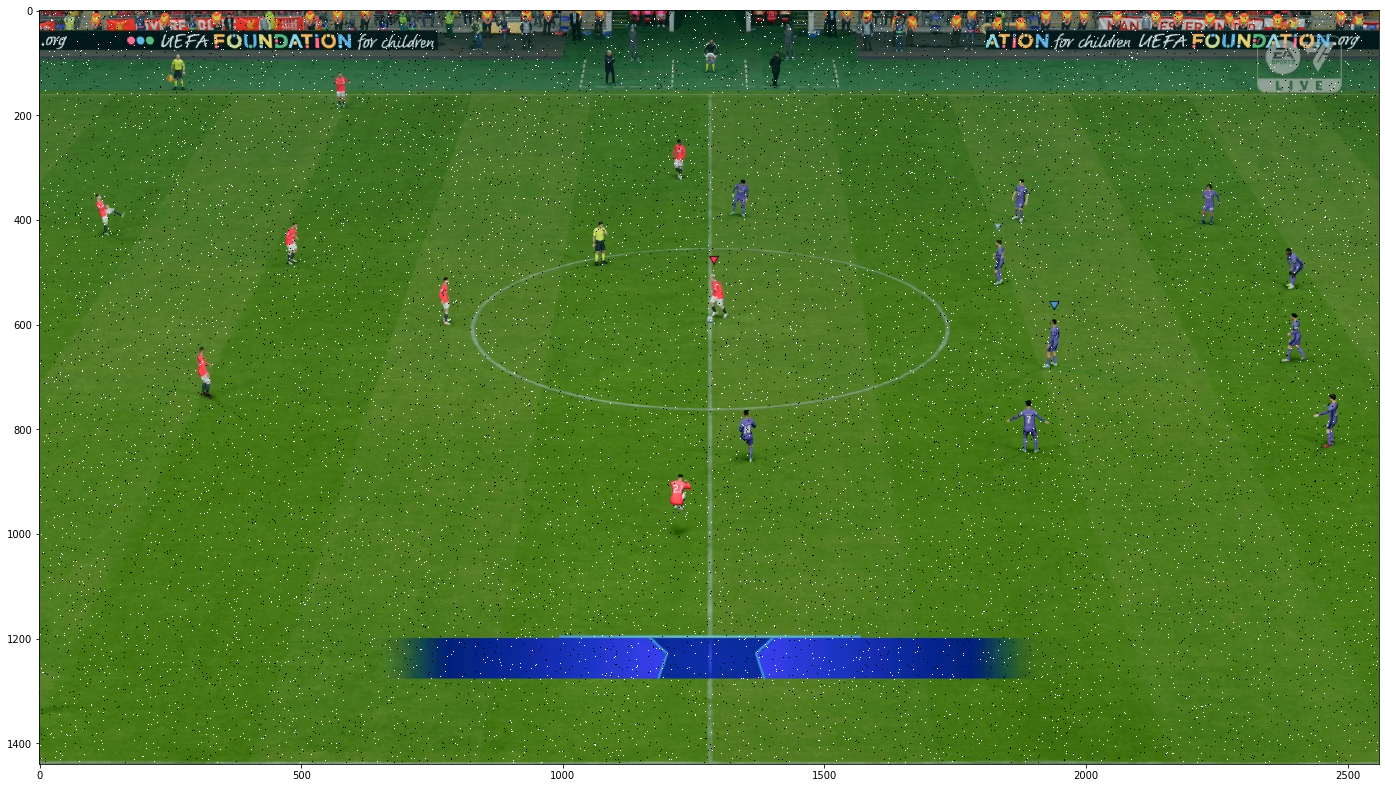

In [34]:
class Salt_pepper(ImageOnlyTransform):
    def apply(self, img, **params):
        return salt_pepper(img)

f = Salt_pepper()
out = f(image= cv2.imread(r"C:\Users\nghuy\OneDrive\Desktop\Merge_COCO\000000000006.png", cv2.COLOR_BGR2RGB))

plt.imshow(out["image"][:,:,::-1])

In [42]:
# 3 types of augmentation
transform = albumentations.Compose([
        albumentations.HueSaturationValue(p=0.5),
        albumentations.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0, p=0.5),
        Salt_pepper()
])

In [43]:
for product in products:
    #print(product)
    product_path = os.path.join(data_path,product)
    pic = cv2.imread(product_path, cv2.COLOR_BGR2RGB)
    for i in range(8):
        transformed_image = transform(image = pic)['image']
        transformed_image_name = product[:-8] + '_transformed_' + str(i) + '.png'
        if generate_data:
            cv2.imwrite(os.path.join(augmented_data_path,transformed_image_name), transformed_image)